 # Tentativo Simple CNN 

 -Inserire descrizione di cosa faremo in questo notebook-

## Import

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

print("FASE 1: Ricerca Dati PROFONDA in LOCALE \n")

DATASET_DIR = '../waste_type_identification' 
OUTPUT_CSV = '../train_val_split.csv'

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"ERRORE: La cartella non si trova all'indirizzo '{DATASET_DIR}'.")

print(f" Directory trovata: {DATASET_DIR}")

class_mapping = {
    'battery': 0, 'clothing': 1, 'glass': 2, 'metal': 3,
    'organic': 4, 'papery': 5, 'plastic': 6, 'undifferentiated': 7
}

data = []
print("Esplorazione profonda delle cartelle in corso...")

for class_name in os.listdir(DATASET_DIR):
    class_dir = os.path.join(DATASET_DIR, class_name)
    
    if os.path.isdir(class_dir) and class_name.lower() in class_mapping:
        label = class_mapping[class_name.lower()]
        
        # IL CAMBIAMENTO È QUI: os.walk esplora tutte le sottocartelle
        for root_dir, dirs, files in os.walk(class_dir):
            for file_name in files:
                # Controlliamo estensioni comuni (aggiunto anche webp per sicurezza)
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    file_path = os.path.join(root_dir, file_name)
                    data.append({'filepath': file_path, 'label': label, 'class_name': class_name.capitalize()})

df = pd.DataFrame(data)

if len(df) == 0:
    raise ValueError(f" CRITICO: La cartella {DATASET_DIR} è vuota o non ci sono immagini.")

print(f" Trovate {len(df)} immagini in totale esplorando tutte le sottocartelle.")

# SPLIT E SALVATAGGIO CSV
print("Esecuzione dello split (80% train, 20% validation) in corso ...")
train_df, val_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)

train_df = train_df.copy(); train_df['split'] = 'train'
val_df = val_df.copy(); val_df['split'] = 'val'

final_df = pd.concat([train_df, val_df])
final_df.to_csv(OUTPUT_CSV, index=False)
print(f" Split completato. File salvato in: {OUTPUT_CSV}")

print("\nDistribuzione reale delle classi nel Training Set:")
print(train_df['class_name'].value_counts())

FASE 1: Ricerca Dati PROFONDA in LOCALE 

 Directory trovata: ../waste_type_identification
Esplorazione profonda delle cartelle in corso...
 Trovate 15515 immagini in totale esplorando tutte le sottocartelle.
Esecuzione dello split (80% train, 20% validation) in corso ...
 Split completato. File salvato in: ../train_val_split.csv

Distribuzione reale delle classi nel Training Set:
class_name
Clothing            5841
Glass               1609
Papery              1553
Organic              788
Battery              756
Plastic              692
Metal                615
Undifferentiated     558
Name: count, dtype: int64


## Caricamento Dataset Split

In [12]:
# Assicuriamoci di usare lo stesso CSV appena creato
OUTPUT_CSV = '../train_val_split.csv'


# Ricarichiamo i dataframe dal CSV
try:
    df = pd.read_csv(OUTPUT_CSV)
    train_df = df[df['split'] == 'train']
    val_df = df[df['split'] == 'val']
    print(f"CSV caricato con successo. Train set: {len(train_df)}, Val set: {len(val_df)}")
except FileNotFoundError:
    raise FileNotFoundError(f"ERRORE: Non trovo il file {OUTPUT_CSV}. Sicuro che la FASE 1 sia andata a buon fine?")

CSV caricato con successo. Train set: 12412, Val set: 3103


## Resize Immagini 128 x 128

In [13]:
print("\n--- FASE 2: Caricamento tensori ---")

# Trasformazioni base: ridimensionamento a 128x128 per velocità  
base_transforms = transforms.Compose([
    transforms.Resize((128, 128)),  #cambia a 224 x 224 per secondo esperimento
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class WasteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self): 
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['filepath']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']
        if self.transform: image = self.transform(image)
        return image, label

BATCH_SIZE = 16 
train_loader = DataLoader(WasteDataset(train_df, transform=base_transforms), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WasteDataset(val_df, transform=base_transforms), batch_size=BATCH_SIZE, shuffle=False)
print("Immagini in memoria e pronte per la rete")


--- FASE 2: Caricamento tensori ---
Immagini in memoria e pronte per la rete


## Costruzione CNN e addestramento

### Adam

In [31]:
print("\n--- FASE 3: Architettura Rete ---")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        # 64 canali * 16 * 16 (dimensione spaziale residua partendo da 128 x 128)
        self.fc1 = nn.Linear(64 * 16 * 16, 128) #quando passi a 224 x 224 , camnbia in self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 8) 

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)

        x = x.view(-1, 64 * 16 * 16) # quando passi a 224 x 224 , cambia in x = x.view(-1, 64 * 28 * 28
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Cerca prima una GPU NVIDIA (Windows/Linux), poi una GPU Mac, altrimenti usa la CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Modello creato. Acceleratore in uso : {device.type.upper()}")


--- FASE 3: Architettura Rete ---
Modello creato. Acceleratore in uso : MPS


### SGD

In [37]:
print("\n--- FASE 3: Architettura Rete ---")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        # 64 canali * 16 * 16 (dimensione spaziale residua partendo da 128 x 128)
        self.fc1 = nn.Linear(64 * 16 * 16, 128) #quando passi a 224 x 224 , camnbia in self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 8) 

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)

        x = x.view(-1, 64 * 16 * 16) # quando passi a 224 x 224 , cambia in x = x.view(-1, 64 * 28 * 28
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Cerca prima una GPU NVIDIA (Windows/Linux), poi una GPU Mac, altrimenti usa la CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
# SGD ottimizzato con Momentum per reti custom
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print(f"Modello creato. Acceleratore in uso : {device.type.upper()}")


--- FASE 3: Architettura Rete ---
Modello creato. Acceleratore in uso : MPS


## Addestramento SimpleCNN pura


In [38]:
# --- Cella 4: Addestramento SimpleCNN  ---

print("\n--- FASE 0: Addestramento SimpleCNN---")

EPOCHS = 10                  # Lasciamo 10, ma l'Early Stopping la fermerà prima se diverge
PATIENCE = 2                 # Tolleranza di peggioramento sulla Validation Loss
best_val_loss = float('inf') # Memoria del minimo storico della Loss
patience_counter = 0

# Rinominato per la Fase 0
BEST_MODEL_PATH = 'simplecnnSGD_weights.pth'

# Dizionari per salvare la history e plotttare il grafico dell'overfitting per il report
history = {'train_loss': [], 'val_loss': [], 'bal_acc': []}

for epoch in range(EPOCHS):
    
    # --- FASE DI TRAINING ---
    model.train()
    running_loss = 0.0
    total_train_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        total_train_loss += loss.item()

        if i % 20 == 19: 
            print(f"  Epoca [{epoch+1}/{EPOCHS}], Batch [{i+1}/{len(train_loader)}], Loss: {running_loss/20:.4f}")
            running_loss = 0.0

    print(f" Epoca {epoch+1} conclusa. Calcolo metriche di validazione...")

    # --- FASE DI VALIDATION ---
    model.eval()
    all_preds = []
    all_labels = []
    total_val_loss = 0.0 

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            val_loss = criterion(outputs, labels)
            total_val_loss += val_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())  # CORRETTO: Spostato su CPU prima di Numpy!
            
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Calcolo medie di fine epoca
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    bal_acc = balanced_accuracy_score(all_labels, all_preds) * 100
            
    # Salvataggio history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bal_acc'].append(bal_acc)

    print(f"--> Riepilogo Epoca {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Balanced Accuracy: {bal_acc:.2f}%\n")
    
    # --- LOGICA DI EARLY STOPPING E SALVATAGGIO ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_preds_memory = all_preds.copy()
        print(f"Val Loss migliorata! Checkpoint ottimale salvato su '{BEST_MODEL_PATH}'\n")
    else:
        patience_counter += 1
        print(f"Val Loss peggiorata o stabile. (Patience: {patience_counter}/{PATIENCE})\n")
        
        if patience_counter >= PATIENCE:
            print(f"EARLY STOPPING INNESCATO ALL'EPOCA {epoch+1}! Interruzione per prevenire Overfitting.")
            break

print("Addestramento concluso!")


--- FASE 0: Addestramento SimpleCNN---
  Epoca [1/10], Batch [20/776], Loss: 1.9147
  Epoca [1/10], Batch [40/776], Loss: 1.6872
  Epoca [1/10], Batch [60/776], Loss: 1.7216
  Epoca [1/10], Batch [80/776], Loss: 1.6858
  Epoca [1/10], Batch [100/776], Loss: 1.6500
  Epoca [1/10], Batch [120/776], Loss: 1.5708
  Epoca [1/10], Batch [140/776], Loss: 1.4971
  Epoca [1/10], Batch [160/776], Loss: 1.6183
  Epoca [1/10], Batch [180/776], Loss: 1.3712
  Epoca [1/10], Batch [200/776], Loss: 1.5528
  Epoca [1/10], Batch [220/776], Loss: 1.5529
  Epoca [1/10], Batch [240/776], Loss: 1.4123
  Epoca [1/10], Batch [260/776], Loss: 1.3549
  Epoca [1/10], Batch [280/776], Loss: 1.4430
  Epoca [1/10], Batch [300/776], Loss: 1.3062
  Epoca [1/10], Batch [320/776], Loss: 1.2973
  Epoca [1/10], Batch [340/776], Loss: 1.2991
  Epoca [1/10], Batch [360/776], Loss: 1.2762
  Epoca [1/10], Batch [380/776], Loss: 1.2274
  Epoca [1/10], Batch [400/776], Loss: 1.2649
  Epoca [1/10], Batch [420/776], Loss: 1.170

## Metriche di Addestramento e Confusion Matrix


CLASSIFICATION REPORT :
                  precision    recall  f1-score   support

         Battery       0.60      0.66      0.63       189
        Clothing       0.87      0.93      0.90      1461
           Glass       0.73      0.65      0.69       402
           Metal       0.45      0.56      0.50       154
         Organic       0.64      0.60      0.62       197
          Papery       0.80      0.68      0.74       388
         Plastic       0.65      0.37      0.47       173
Undifferentiated       0.61      0.76      0.68       139

        accuracy                           0.77      3103
       macro avg       0.67      0.65      0.65      3103
    weighted avg       0.77      0.77      0.77      3103



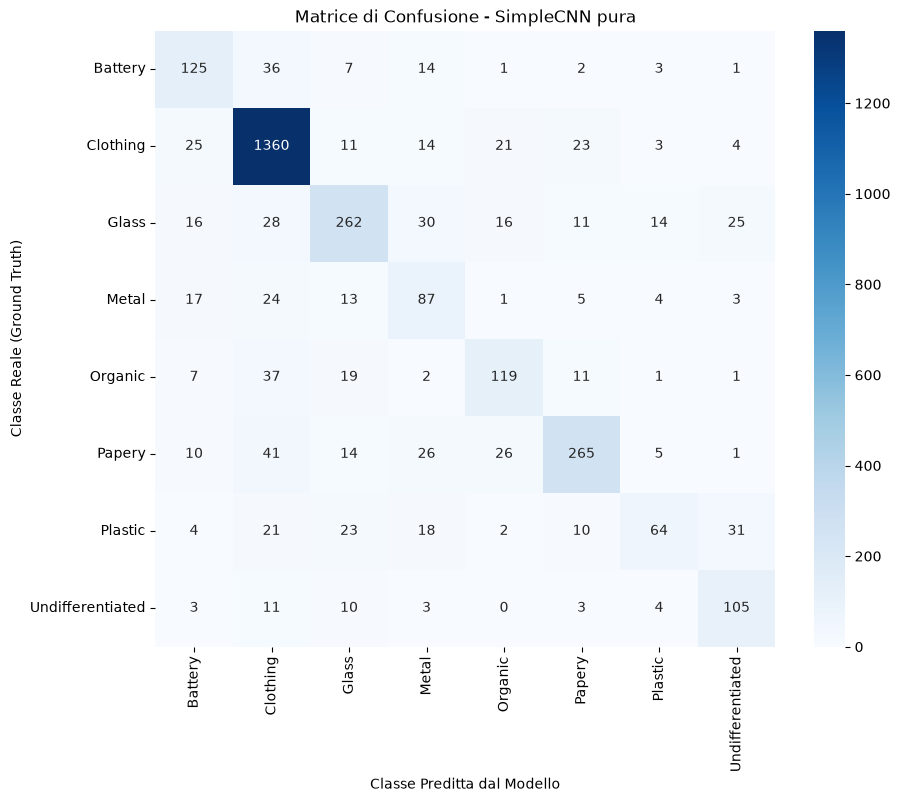

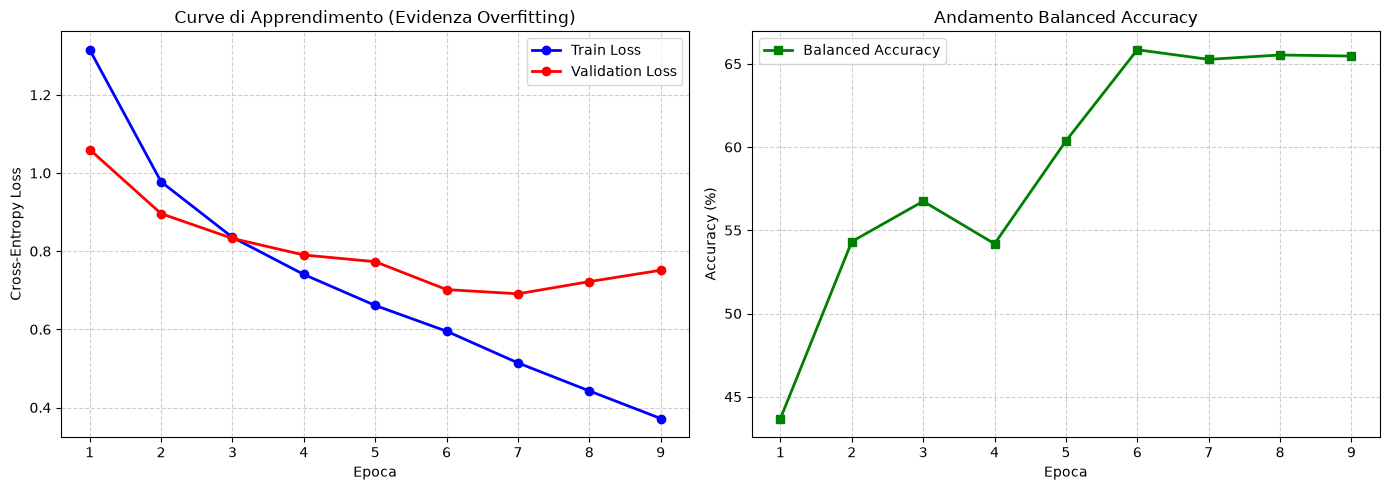

In [39]:
########## DA ESEGUIRE PER LE METRICHE DI UN ADDESTRAMENTO ##############

# Nomi delle classi ordinati dal dizionario class_mapping (0 fino a 7)
class_names = ['Battery', 'Clothing', 'Glass', 'Metal', 'Organic', 'Papery', 'Plastic', 'Undifferentiated']

# 1. Report completo accademico (Precision, Recall, F1-Score per ogni singola classe)
print("\nCLASSIFICATION REPORT :")
print(classification_report(all_labels, best_preds_memory, target_names=class_names))

# 2. Matrice di Confusione
cm = confusion_matrix(all_labels, best_preds_memory)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice di Confusione - SimpleCNN pura")
plt.ylabel("Classe Reale (Ground Truth)")
plt.xlabel("Classe Preditta dal Modello")
plt.show()

# Creiamo una lista che va da 1 fino al numero esatto di epoche completate
epoche = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# GRAFICO 1: LOSS
plt.subplot(1, 2, 1)
# Aggiungiamo 'epoche' come primo parametro (asse X)
plt.plot(epoche, history['train_loss'], label='Train Loss', color='blue', marker='o', linewidth=2)
plt.plot(epoche, history['val_loss'], label='Validation Loss', color='red', marker='o', linewidth=2)
plt.title('Curve di Apprendimento (Evidenza Overfitting)')
plt.xlabel('Epoca')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(epoche) # <-- TRUCCO: Forza i "tic" dell'asse X a essere esattamente 1, 2, 3...
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# GRAFICO 2: ACCURACY
plt.subplot(1, 2, 2)
# Aggiungiamo 'epoche' anche qui
plt.plot(epoche, history['bal_acc'], label='Balanced Accuracy', color='green', marker='s', linewidth=2)
plt.title('Andamento Balanced Accuracy')
plt.xlabel('Epoca')
plt.ylabel('Accuracy (%)')
plt.xticks(epoche) # <-- TRUCCO
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Analisi Immagini


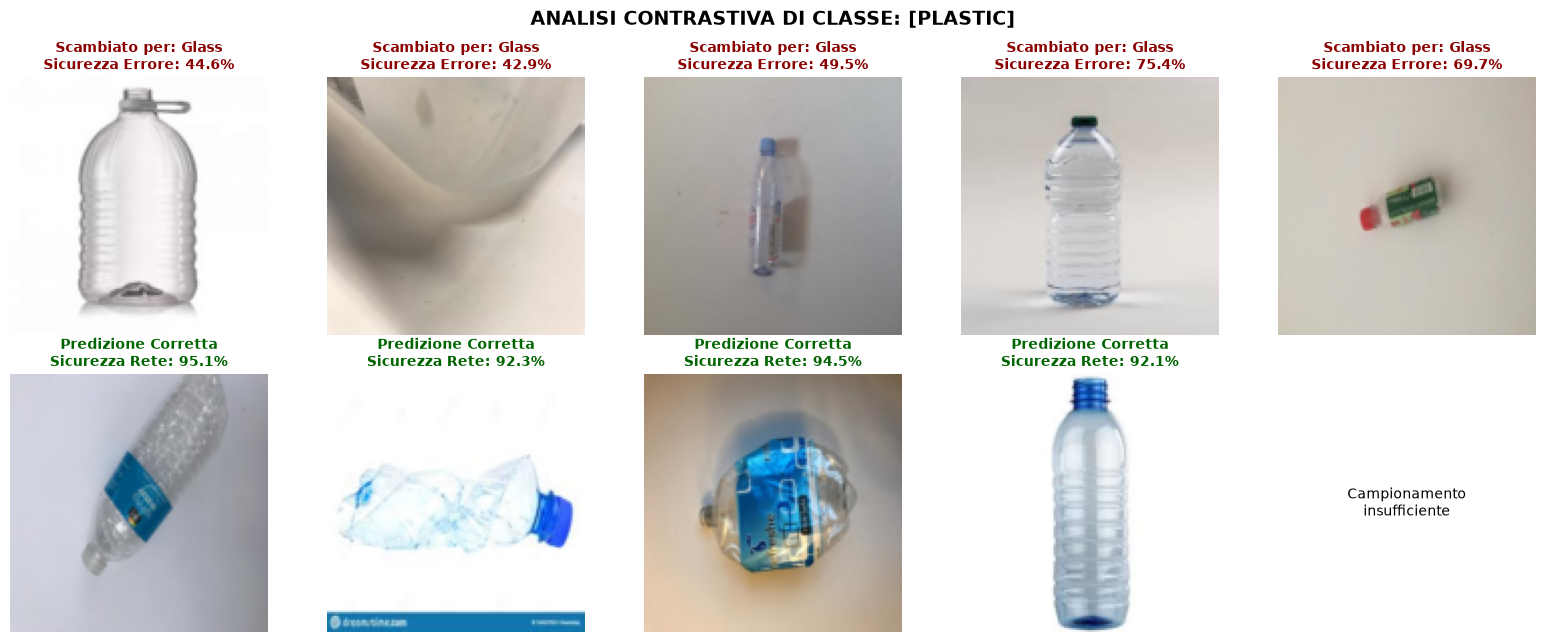

In [30]:


################# ANALISI IMMAGINI ##################

def contrastive_error_forensics(model, val_loader, device, class_names, true_class, confused_class, samples_per_row=5):
    """
    Confronta visivamente i campioni falliti con i campioni perfetti della stessa classe.
    """
    model.eval()
    true_idx = class_names.index(true_class)
    conf_idx = class_names.index(confused_class)
    
    mistakes_img, mistakes_conf = [], []
    corrects_img, corrects_conf = [], []
    
    # Costanti di denormalizzazione ImageNet
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs_dev = inputs.to(device)
            outputs = model(inputs_dev)
            probs = F.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, 1)
            
            for i in range(len(labels)):
                lbl = labels[i].item()
                prd = preds[i].item()
                cnf = confs[i].item() * 100
                
                # Caso A: Errore mirato (True Class -> Confused Class)
                if lbl == true_idx and prd == conf_idx and len(mistakes_img) < samples_per_row:
                    img = torch.clamp(inputs[i].cpu() * std + mean, 0, 1).permute(1, 2, 0).numpy()
                    mistakes_img.append(img)
                    mistakes_conf.append(cnf)
                
                # Caso B: Benchmark di perfezione (True Class -> True Class con altissima sicurezza)
                elif lbl == true_idx and prd == true_idx and cnf > 92.0 and len(corrects_img) < samples_per_row:
                    img = torch.clamp(inputs[i].cpu() * std + mean, 0, 1).permute(1, 2, 0).numpy()
                    corrects_img.append(img)
                    corrects_conf.append(cnf)
                    
                if len(mistakes_img) == samples_per_row and len(corrects_img) == samples_per_row:
                    break
            if len(mistakes_img) == samples_per_row and len(corrects_img) == samples_per_row:
                break

    # Creazione della tavola ottica comparativa
    fig, axes = plt.subplots(2, samples_per_row, figsize=(16, 6.5))
    fig.suptitle(f"ANALISI CONTRASTIVA DI CLASSE: [{true_class.upper()}]", fontsize=14, fontweight='bold', y=0.98)
    
    # Render Riga 1: Gli Errori
    for idx in range(samples_per_row):
        ax = axes[0, idx]
        if idx < len(mistakes_img):
            ax.imshow(mistakes_img[idx])
            ax.set_title(f"Scambiato per: {confused_class}\nSicurezza Errore: {mistakes_conf[idx]:.1f}%", color='darkred', fontweight='bold', fontsize=10)
        else:
            ax.text(0.5, 0.5, "Nessun altro\nerrore trovato", ha='center', va='center')
            
        ax.axis('off')
        if idx == 0: ax.set_ylabel("FALLIMENTI", fontsize=12, fontweight='bold', color='red')

    # Render Riga 2: I Successi
    for idx in range(samples_per_row):
        ax = axes[1, idx]
        if idx < len(corrects_img):
            ax.imshow(corrects_img[idx])
            ax.set_title(f"Predizione Corretta\nSicurezza Rete: {corrects_conf[idx]:.1f}%", color='darkgreen', fontweight='bold', fontsize=10)
        else:
            ax.text(0.5, 0.5, "Campionamento\ninsufficiente", ha='center', va='center')
            
        ax.axis('off')
        if idx == 0: ax.set_ylabel("BENCHMARK", fontsize=12, fontweight='bold', color='green')

    plt.tight_layout()
    plt.show()

# --- ESEGUI IL TEST CONTRASTIVO ---
# Sostituisci 'Plastic' e 'Glass' con la coppia critica che vedi spuntare dalla tua Matrice di Confusione!
class_names = ['Battery', 'Clothing', 'Glass', 'Metal', 'Organic', 'Papery', 'Plastic', 'Undifferentiated']

contrastive_error_forensics(model, val_loader, device, class_names, true_class='Plastic', confused_class='Glass')

## Import